In [170]:
import requests
from lxml import etree

"""Stage1 - 准备图片数据"""
image_web_url = "https://cn.bing.com/images/async"   #特别之神奇，换成async就不需要很多pagenum了
headers ={
        "User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/141.0.0.0 Safari/537.36 Edg/141.0.0.0"
        }
keywords = ["东坡肉图片","麻婆豆腐图片","可乐鸡翅图片"]

num_train = 40
train_urls = []
num_val = 20
val_urls = []

num_pages = 3

for keyword in keywords:
    image_urls = []
    for page in range(num_pages):
        param = {
            "q": keyword,
            "first": page * 35 + 1,
            "mmasync": 1
        }
        response = requests.get(image_web_url, params=param, headers=headers)   #利用搜索引擎，自动搜索，不用把那几串超长的响应地址写下来
        text = response.text
        text_html = etree.HTML(text)
        urls = text_html.xpath("//img[contains(@class, 'mimg')]/@src")  #模糊匹配
        image_urls.extend(urls)
    #去重
    image_urls = list(dict.fromkeys(image_urls))  #字典去重法，最后转回列表形式
    train_urls.append(image_urls[:num_train])
    val_urls.append(image_urls[num_train : num_train+num_val])



In [171]:
# """保存训练数据集"""
# for i,urls in enumerate(train_urls):
#     for j,url in enumerate(urls):
#         img_data = requests.get(url,headers=headers)  #图片数据需要重新请求
#         with open (f'/workspace/cs231n/self-defined-datasets/train/class{i+1}/img{j+1}.jpg', "wb")as f:
#             f.write(img_data.content)

In [172]:
# """保存验证数据集"""
# for i,urls in enumerate(val_urls):
#     for j,url in enumerate(urls):
#         img_data = requests.get(url,headers=headers)
#         with open (f'/workspace/cs231n/self-defined-datasets/val/class{i+1}/img{j+1}.jpg', "wb")as f:  #以wb二进制形式保存图片
#             f.write(img_data.content)

In [ ]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms as T
import os   #os对目录，文件，路径进行操作
import random
from PIL import Image       #Python Image Library用来加载图片，转换图片格式，调整图片大小角度等

"""Stage2 - 数据集类继承torch的Dataset"""

class ChineseFoodDataset(Dataset):
    def __init__(self, root_dir, train=True, transform=None):
        self.rootdir = root_dir
        self.mode = 'train' if train==True else 'val'
        self.transform = transform
        self.split_dir = os.path.join(root_dir, self.mode)
        
        self.image_paths = []
        self.labels = []
        
        self.classes = os.listdir(self.split_dir)
        
        for i, class_name in enumerate(self.classes):
            class_dir = os.path.join(self.split_dir, class_name)
            for filename in os.listdir(class_dir):
                self.image_paths.append(os.path.join(class_dir, filename))
                self.labels.append(i)
        self.shuffle_paths()
         
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, index):
        img_path = self.image_paths[index]
        label = self.labels[index]
        try:
            img = Image.open(img_path)  #Image将图片以数字矩阵形式保存
            if img.mode != 'RGB':   #非RGB模式，强制转化
                img = img.convert('RGB')
        except:
            print('图片损坏无法读取!, 将创建占位图片')  #处理损坏图片
            img= Image.new('RGB', (250,180), color=(128,128,128))  #Image还能创建新的纯色图片，128是灰色，大小我采用下载下来的图片大小折中了下
        
        if self.transform:
            img = self.transform(img)
        return img, label
    
    def shuffle_paths(self):   # 当我发现生成了巨量东坡肉时我发现了不对劲。
        indices = list(range(len(self.image_paths)))
        random.shuffle(indices)
        self.image_paths = [self.image_paths[i] for i in indices]
        self.labels = [self.labels[j] for j in indices]


40


In [ ]:
""" torchvision.transforms - 数据增强"""

transform = T.Compose([        #此处啰嗦供自我记录用，不参与实际增强策略
    # T.Resize(180),   # 指定图像短边，长边根据比例调整
    # T.CenterCrop(200),   # 中心裁剪，使图片到这个形状
    T.RandomRotation(degrees=15),  # 随机旋转-15到15度
    # T.RandomHorizontalFlip(p=0.5),  # 随机水平翻转，概率是50%
    T.RandomVerticalFlip(p=0.5),
    T.RandomResizedCrop(size=180,scale=(0.5,0.8)),  # 随机裁剪并缩放，size是缩放到尺寸，scale是要裁剪的窗口占原图范围，即把原图的50~80%部分裁掉，增强对局部特征的提取
    
    T.ColorJitter(
        brightness=0.2,  # 亮度调整幅度±20%
        contrast=0.3,   # 对比度调整幅度±30%
        saturation=0.3,   # 饱和度调整幅度±30%
        hue=0.1      # hue值范围必须在0~0.5，0.1表示色相会在±0.1范围内调整，因为色相值范围就是-0.5~0.5
    ),
    
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

In [183]:
"""albumentations - 数据增强"""
#待学习(

'albumentations - 数据增强'

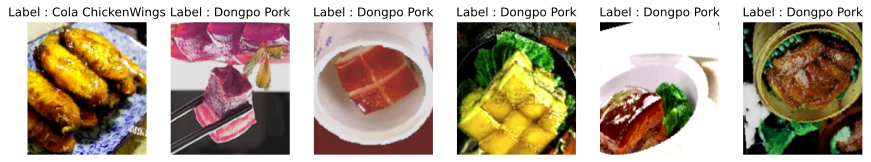

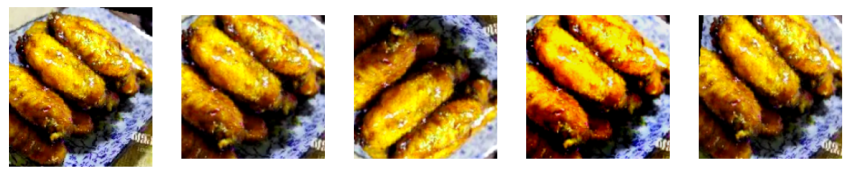

In [198]:
dataset = ChineseFoodDataset('./cs231n/self-defined-datasets', train=True, transform=transform)
loader_train = DataLoader(dataset, batch_size=6)

"""可视化一个Batch数据"""

import matplotlib.pyplot as plt
# %matplotlib inline 
from matplotlib_inline import backend_inline   
backend_inline.set_matplotlib_formats('svg')

class_names = ['Dongpo Pork','Mapo Tofu', 'Cola ChickenWings']

def Visualize_OneBatch(dataloader, class_names):
    for batch_images, batch_labels in dataloader:  #只取一个batch，所以直接break
        mean = torch.tensor([0.4914, 0.4822, 0.4465]).reshape(1, 3, 1, 1)   #归一化时采用的是SBN,这个列表即running_mean,running_var,每个通道一个统计量
        std = torch.tensor([0.2023, 0.1994, 0.2010]).reshape(1, 3, 1, 1)  #重塑增加维度后能广播，参与反标准化，使数据正常显示
        batch_images = batch_images * std + mean   #反标准化容易产生浮点误差！需要clamp调整范围
        batch_images = torch.clamp(batch_images, 0, 1)
        batch_images = batch_images.numpy().transpose(0, 2, 3, 1)   #转为np数组，同时转为(N, H, W, C)形状，便于正常显示
        
        One_image = batch_images[0]  # 偷懒直接从加载完的取一张再进行特征增强展示不同策略的效果。
        PIL = T.ToPILImage()  #需要创建实例
        One_image = PIL(One_image)  #因为经过一轮增强了已经是张量形式，要转成PIL的图像形式
        One_label = batch_labels[0]
        strategies = [
            T.Compose([T.Resize((250)), 
                       T.CenterCrop((220))]),  #先等比放大再裁剪得到中心区域，形变最小化而且固定尺寸
            T.Compose([
                T.RandomVerticalFlip(p=1.0),  # 100%翻转
                T.Resize(250),
                T.CenterCrop(220)
            ]),
            T.Compose([
                T.ColorJitter(brightness=0.3, contrast=0.5, saturation=0.4), #颜色系数调整
                T.Resize(250),
                T.CenterCrop(220)
            ]),
            T.Compose([
                T.RandomRotation(10),  #旋转＋裁剪
                T.RandomResizedCrop(220, scale=(0.4, 0.8)),
            ]),
                    ]   
        
        fig1, ax1 = plt.subplots(1, 6, figsize=(15, 5))
        fig2, ax2 = plt.subplots(1, len(strategies)+1, figsize=(15,5))
        for i in range(6):
            ax1[i].imshow(batch_images[i])
            ax1[i].set_title(f'Label : {class_names[batch_labels[i]]}')
            ax1[i].axis('off') #关闭坐标轴，更美观
            
        ax2[0].imshow(One_image)  
        ax2[0].axis('off')  
        for j, strategy in enumerate(strategies):
            transformed_img = strategy(One_image)
            ax2[j+1].imshow(transformed_img)
            ax2[j+1].axis('off')
            
        break
    
if __name__ == "__main__":
    Visualize_OneBatch(loader_train, class_names)
